In [98]:
import pandas as pd
import numpy as np

In [99]:
df = pd.read_csv('features.csv')

# Filter where the first column equals "Linear"
linear = df[df.iloc[:, 0] == "Linear"].copy()


In [109]:
# Select input features (X) and output conditions (y)
X = linear.iloc[:, 3:linear.shape[1]]
y = linear.iloc[:, 1]

X.head(5)

,PlateHFAccZ_mean,PlateHFAccZ_rms,PlateHFAccZ_std,PlateLFAccX_mean,PlateLFAccX_rms,PlateLFAccX_std,PlateLFAccY_mean,PlateLFAccY_rms,PlateLFAccY_std,PlateLFAccZ_mean,...,Power_std,SpindleAccX_mean,SpindleAccX_rms,SpindleAccX_std,SpindleAccY_mean,SpindleAccY_rms,SpindleAccY_std,SpindleAccZ_mean,SpindleAccZ_rms,SpindleAccZ_std
0,-0.144735,0.145728,0.016981,-0.008171,0.009719,0.005263,-0.019464,0.019542,0.001754,-0.010579,...,0.069790,-0.018440,0.252729,0.252055,-0.011944,0.033116,0.030887,0.036190,0.069887,0.059787
1,-0.144676,0.145680,0.017069,-0.008094,0.010218,0.006236,-0.019435,0.019515,0.001765,-0.010620,...,0.001224,-0.022908,0.253962,0.252927,-0.011348,0.033081,0.031074,0.035300,0.069057,0.059353
2,-0.144918,0.145916,0.017040,-0.007979,0.009186,0.004553,-0.019419,0.019497,0.001744,-0.010628,...,0.001071,-0.022749,0.254043,0.253023,-0.011572,0.033221,0.031140,0.034759,0.068992,0.059596
3,-0.144847,0.145838,0.016966,-0.008027,0.009314,0.004724,-0.019534,0.019612,0.001749,-0.010633,...,0.001445,-0.022813,0.254034,0.253008,-0.011477,0.033051,0.030994,0.034736,0.069030,0.059654
4,-0.145517,0.146515,0.017077,-0.008075,0.009237,0.004487,-0.019451,0.019529,0.001743,-0.010682,...,0.002632,-0.022567,0.253980,0.252976,-0.011395,0.033213,0.031197,0.034955,0.069064,0.059565


In [101]:
from sklearn.model_selection import train_test_split

# Apply random 65:35 (training:test) split to the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=21)

In [102]:
# Normalise all variables
from sklearn.preprocessing import StandardScaler

scale_standard = StandardScaler()

X_train = scale_standard.fit_transform(X_train)


# Revert back to pandas data frame
X_train = pd.DataFrame(X_train, columns=[X.columns.values.tolist()])


In [103]:
from sklearn.decomposition import PCA

# Compute a 3 component PCA
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_train)

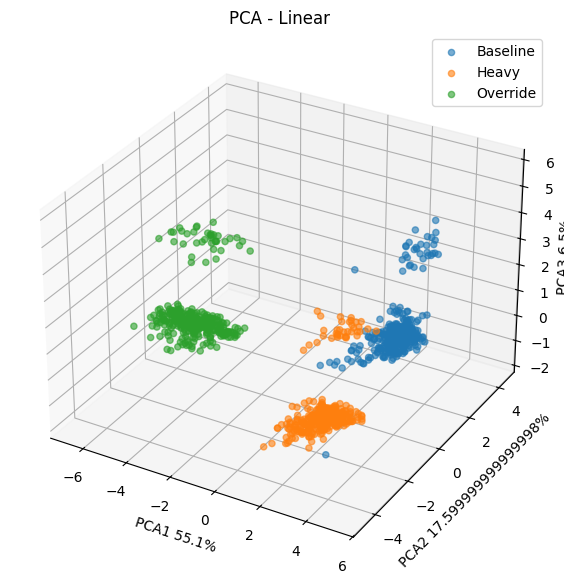

In [104]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12,7))
ax = fig.add_subplot(111, projection='3d')

# Loop through each unique category and plot them separately
for condition in np.unique(y_train):
    # Create a mask to isolate only the current condition's rows
    mask = (y_train == condition)
    ax.scatter(
        X_pca[mask, 0], 
        X_pca[mask, 1], 
        X_pca[mask, 2],      
        label=condition, 
        alpha=0.6
    )

# Label all axes with percentage of explained variance
ax.set_xlabel(f'PCA1 {pca.explained_variance_ratio_[0].round(3)*100}%')
ax.set_ylabel(f'PCA2 {pca.explained_variance_ratio_[1].round(3)*100}%')
ax.set_zlabel(f'PCA3 {pca.explained_variance_ratio_[2].round(3)*100}%', labelpad=-1)
# Graph title
ax.set_title("PCA - Linear")

# Add a legend
ax.legend(loc='upper right')
plt.show()

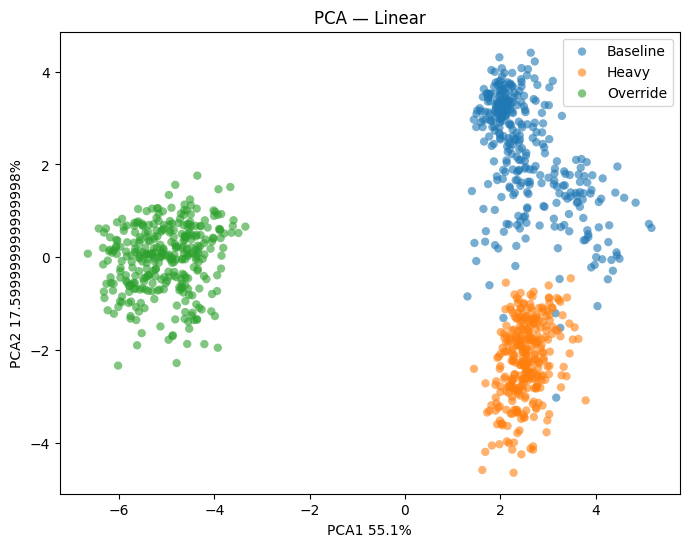

In [105]:
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_train)

fig, ax = plt.subplots(figsize=(8, 6))

# Loop through each unique category and plot them separately
for condition in np.unique(y_train):
    # Create a mask to isolate only the current condition's rows
    mask = (y_train == condition)
    
    # Plot just this group
    ax.scatter(
        X_pca[mask, 0], 
        X_pca[mask, 1], 
        label=condition,      
        alpha=0.6,           
        edgecolors='none'     
    )

# Standard axis labeling
ax.set_xlabel(f'PCA1 {pca.explained_variance_ratio_[0].round(3)*100}%')
ax.set_ylabel(f'PCA2 {pca.explained_variance_ratio_[1].round(3)*100}%')
ax.set_title('PCA — Linear')

# Add a legend
ax.legend(loc='upper right', scatterpoints=1, frameon=True)

plt.show()